## Heart Diseases Prediction

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib .pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [10]:
df = pd.read_csv('Heart Diseases Prediction Dataset.csv')
df

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
0,49,0.0,3.0,129.0,168.0,0.0,1.0,147.0,0.0,1.1,0
1,67,1.0,1.0,147.0,228.0,0.0,0.0,119.0,0.0,0.9,1
2,62,0.0,3.0,109.0,171.0,0.0,1.0,129.0,1.0,3.2,1
3,49,1.0,3.0,126.0,239.0,0.0,2.0,130.0,0.0,0.5,1
4,40,0.0,4.0,119.0,182.0,0.0,1.0,165.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
49995,48,1.0,1.0,126.0,185.0,0.0,0.0,139.0,0.0,0.1,1
49996,57,1.0,3.0,95.0,208.0,0.0,0.0,187.0,0.0,0.6,0
49997,67,1.0,1.0,NaN,212.0,0.0,2.0,169.0,0.0,0.9,1
49998,46,1.0,4.0,120.0,161.0,1.0,0.0,149.0,0.0,NaN,0


## Data Understanding

In [11]:
df.shape

(50000, 11)

In [12]:
df.head(5)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
0,49,0.0,3.0,129.0,168.0,0.0,1.0,147.0,0.0,1.1,0
1,67,1.0,1.0,147.0,228.0,0.0,0.0,119.0,0.0,0.9,1
2,62,0.0,3.0,109.0,171.0,0.0,1.0,129.0,1.0,3.2,1
3,49,1.0,3.0,126.0,239.0,0.0,2.0,130.0,0.0,0.5,1
4,40,0.0,4.0,119.0,182.0,0.0,1.0,165.0,1.0,0.0,0


In [13]:
df.tail(5)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
49995,48,1.0,1.0,126.0,185.0,0.0,0.0,139.0,0.0,0.1,1
49996,57,1.0,3.0,95.0,208.0,0.0,0.0,187.0,0.0,0.6,0
49997,67,1.0,1.0,NaN,212.0,0.0,2.0,169.0,0.0,0.9,1
49998,46,1.0,4.0,120.0,161.0,1.0,0.0,149.0,0.0,NaN,0
49999,61,1.0,1.0,176.0,329.0,0.0,NaN,130.0,0.0,1.0,1


In [14]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression', 'target'],
      dtype='object')

In [15]:
df.dtypes

age                      int64
sex                    float64
chest_pain_type        float64
resting_bp             float64
cholesterol            float64
fasting_blood_sugar    float64
resting_ecg            float64
max_heart_rate         float64
exercise_angina        float64
st_depression          float64
target                   int64
dtype: object

In [16]:
df.size

550000

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  50000 non-null  int64  
 1   sex                  49277 non-null  float64
 2   chest_pain_type      48070 non-null  float64
 3   resting_bp           48464 non-null  float64
 4   cholesterol          47466 non-null  float64
 5   fasting_blood_sugar  48737 non-null  float64
 6   resting_ecg          48203 non-null  float64
 7   max_heart_rate       48056 non-null  float64
 8   exercise_angina      48470 non-null  float64
 9   st_depression        47735 non-null  float64
 10  target               50000 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.2 MB


In [18]:
df.describe()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
count,50000.000000,49277.000000,48070.000000,48464.000000,47466.000000,48737.000000,48203.000000,48056.000000,48470.000000,47735.000000,50000.000000
mean,52.703300,0.649837,2.517038,129.174893,243.499431,0.214601,0.692384,149.395643,0.359686,1.236298,0.448520
std,10.008954,0.477026,1.085743,17.957435,51.943448,0.410549,0.750429,23.084176,0.479913,1.024074,0.497348
min,18.000000,0.000000,1.000000,50.000000,70.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,2.000000,117.000000,209.000000,0.000000,0.000000,134.000000,0.000000,0.500000,0.000000
50%,53.000000,1.000000,3.000000,129.000000,243.000000,0.000000,1.000000,150.000000,0.000000,1.000000,0.000000
75%,59.000000,1.000000,3.000000,141.000000,277.000000,0.000000,1.000000,165.000000,1.000000,1.700000,1.000000
max,90.000000,1.000000,4.000000,260.000000,600.000000,1.000000,2.000000,230.000000,1.000000,10.000000,1.000000


In [19]:
df.corr(numeric_only = True)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
age,1.000000,-0.000860,-0.114640,0.088271,0.067668,0.056317,0.068522,-0.124423,0.117507,0.149735,0.334466
sex,-0.000860,1.000000,-0.006617,0.004718,0.003074,0.007286,-0.000706,-0.000258,-0.007137,0.002733,-0.005512
chest_pain_type,-0.114640,-0.006617,1.000000,-0.089215,-0.065654,-0.060383,-0.067139,0.127538,-0.116715,-0.155105,-0.340274
resting_bp,0.088271,0.004718,-0.089215,1.000000,0.053252,0.046138,0.056021,-0.097173,0.103089,0.128972,0.270612
cholesterol,0.067668,0.003074,-0.065654,0.053252,1.000000,0.043398,0.032760,-0.066295,0.078742,0.093673,0.193996
fasting_blood_sugar,0.056317,0.007286,-0.060383,0.046138,0.043398,1.000000,0.029564,-0.071955,0.069598,0.078138,0.179625
resting_ecg,0.068522,-0.000706,-0.067139,0.056021,0.032760,0.029564,1.000000,-0.074198,0.077064,0.089444,0.198760
max_heart_rate,-0.124423,-0.000258,0.127538,-0.097173,-0.066295,-0.071955,-0.074198,1.000000,-0.137954,-0.175535,-0.380979
exercise_angina,0.117507,-0.007137,-0.116715,0.103089,0.078742,0.069598,0.077064,-0.137954,1.000000,0.168969,0.363693
st_depression,0.149735,0.002733,-0.155105,0.128972,0.093673,0.078138,0.089444,-0.175535,0.168969,1.000000,0.453888


In [20]:
df.isna().sum()

age                       0
sex                     723
chest_pain_type        1930
resting_bp             1536
cholesterol            2534
fasting_blood_sugar    1263
resting_ecg            1797
max_heart_rate         1944
exercise_angina        1530
st_depression          2265
target                    0
dtype: int64

In [21]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression', 'target'],
      dtype='object')

In [22]:
a =['age','sex', 'chest_pain_type','fasting_blood_sugar', 'resting_ecg','exercise_angina']
for i in a :
    print([i])
    print(df[i].unique())

['age']
[49 67 62 40 54 31 43 46 34 60 66 59 68 57 42 63 56 52 58 47 53 45 38 65
 64 51 55 48 70 41 37 69 61 50 32 28 71 39 44 35 72 29 73 33 30 80 77 79
 36 74 76 78 75 85 90 18 88 19]
['sex']
[ 0.  1. nan]
['chest_pain_type']
[ 3.  1.  4. nan  2.]
['fasting_blood_sugar']
[ 0.  1. nan]
['resting_ecg']
[ 1.  0.  2. nan]
['exercise_angina']
[ 0.  1. nan]


In [23]:
a = ['sex', 'chest_pain_type','fasting_blood_sugar', 'resting_ecg','exercise_angina']
for i in a :
    print([i])
    print(df[i].value_counts())

['sex']
sex
1.0    32022
0.0    17255
Name: count, dtype: int64
['chest_pain_type']
chest_pain_type
3.0    13651
2.0    12088
4.0    11178
1.0    11153
Name: count, dtype: int64
['fasting_blood_sugar']
fasting_blood_sugar
0.0    38278
1.0    10459
Name: count, dtype: int64
['resting_ecg']
resting_ecg
0.0    23267
1.0    16497
2.0     8439
Name: count, dtype: int64
['exercise_angina']
exercise_angina
0.0    31036
1.0    17434
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

['sex']


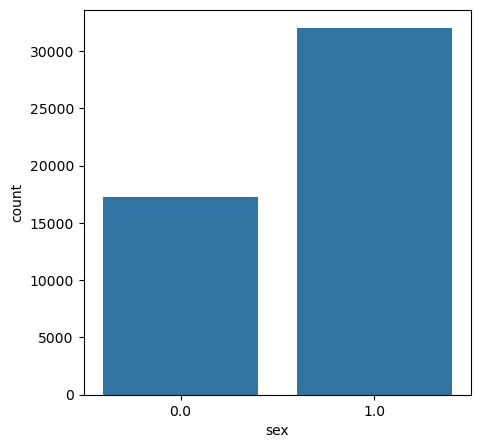

['chest_pain_type']


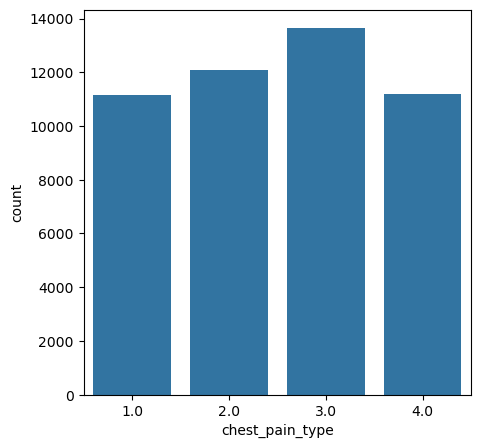

['fasting_blood_sugar']


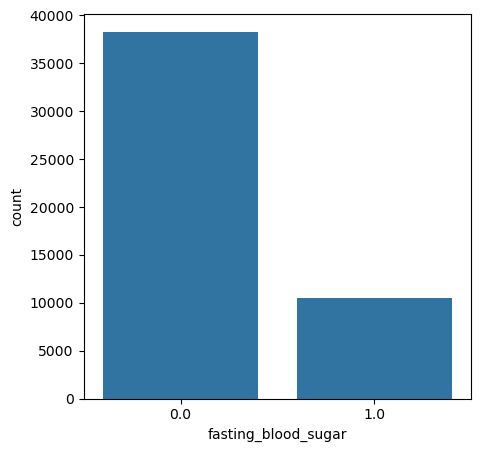

['resting_ecg']


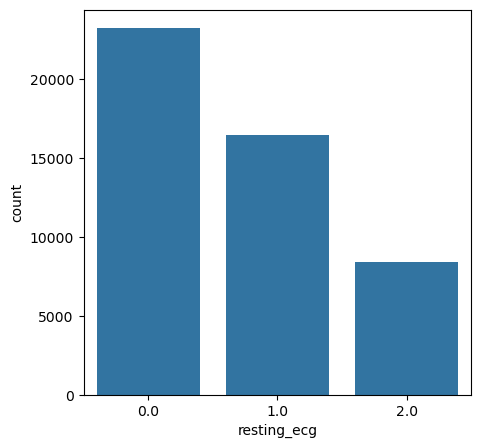

['exercise_angina']


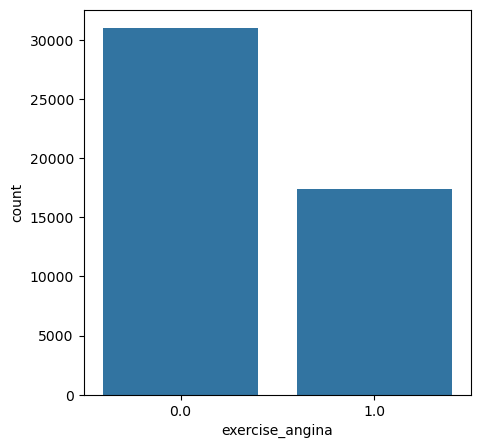

In [24]:
a = ['sex', 'chest_pain_type','fasting_blood_sugar', 'resting_ecg','exercise_angina']
for i in a :
    print([i])
    plt.figure(figsize=(5,5))
    sns.countplot(x=df[i])
    plt.show()

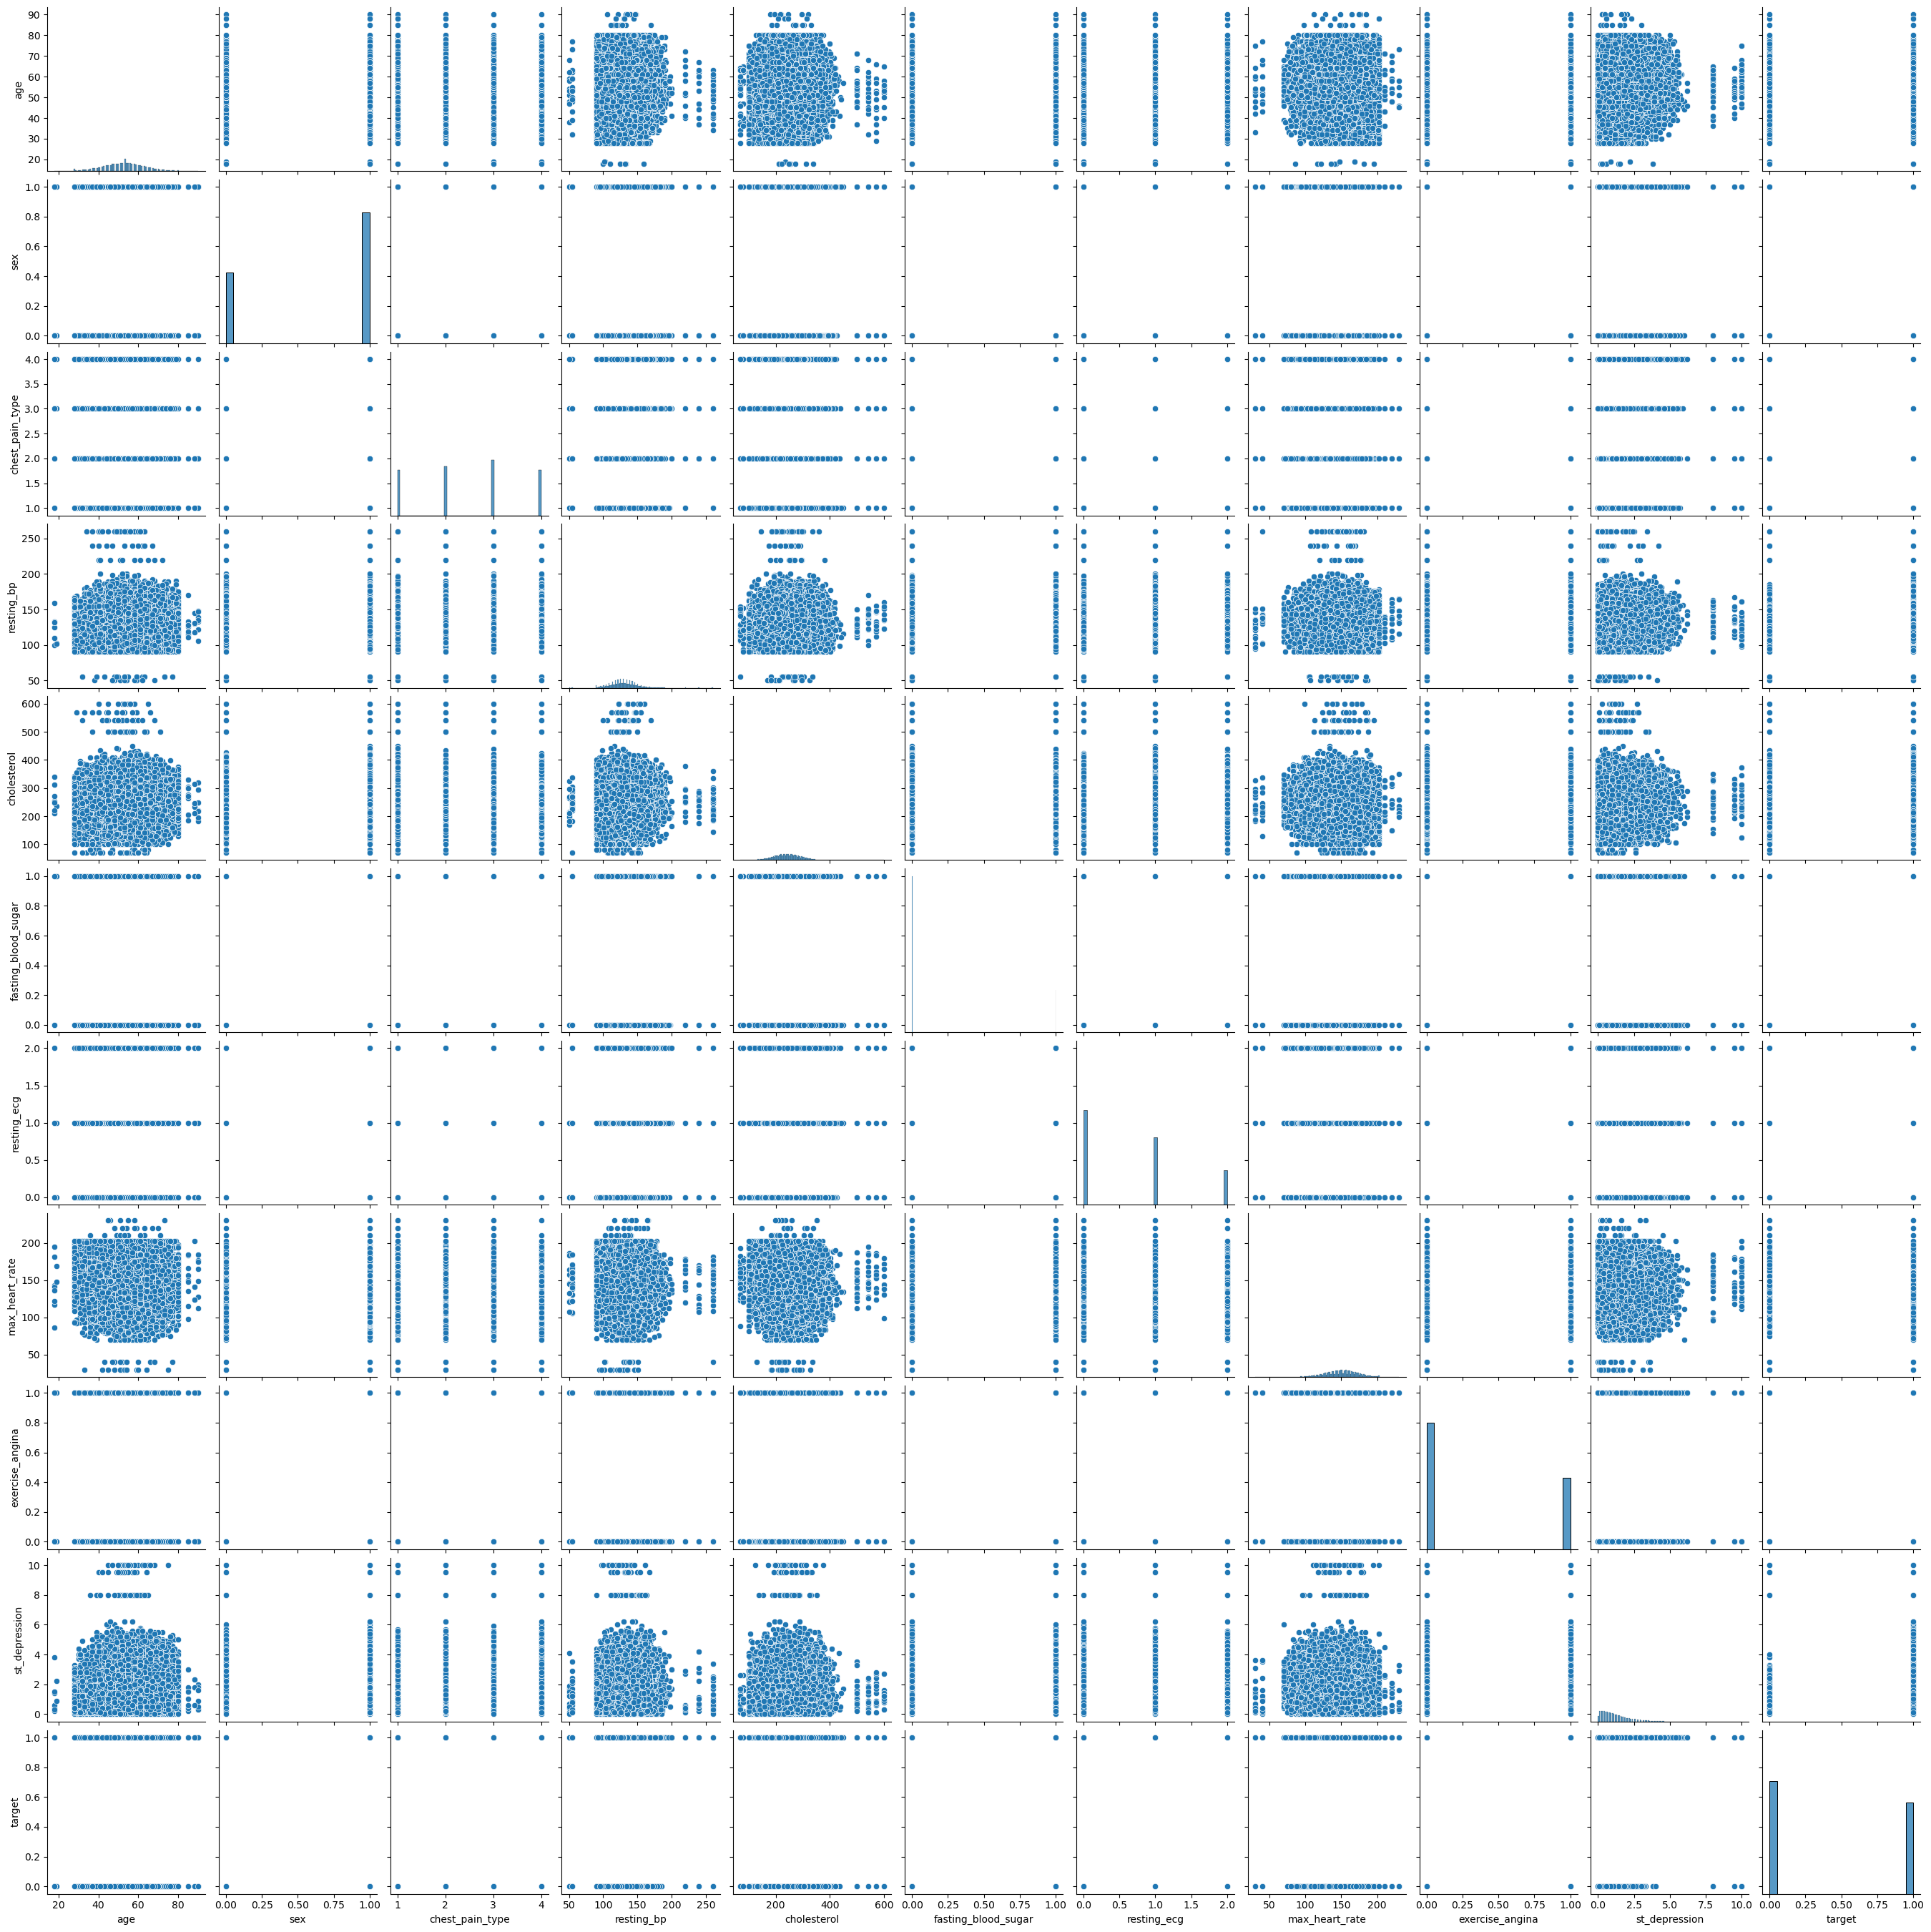

In [25]:
sns.pairplot(df)

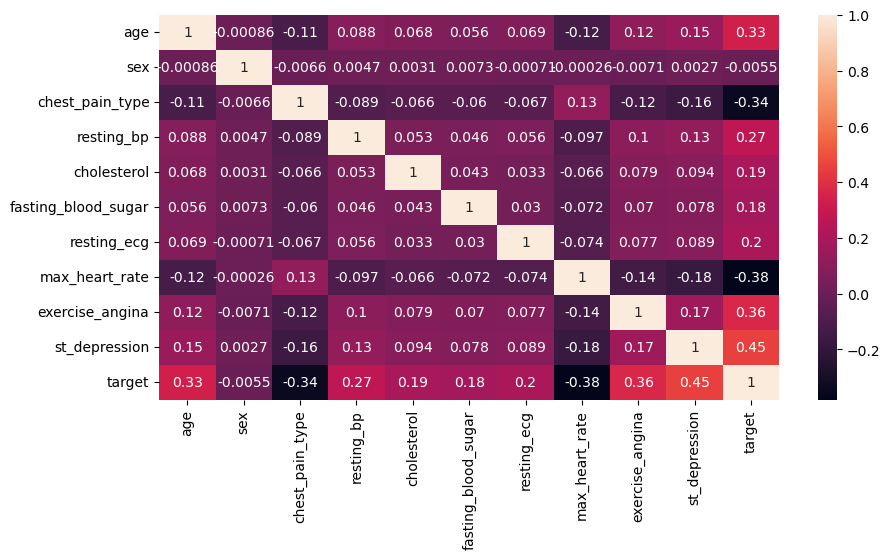

In [26]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only =True),annot =True)
plt.show()

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression', 'target'],
      dtype='object')

['age']


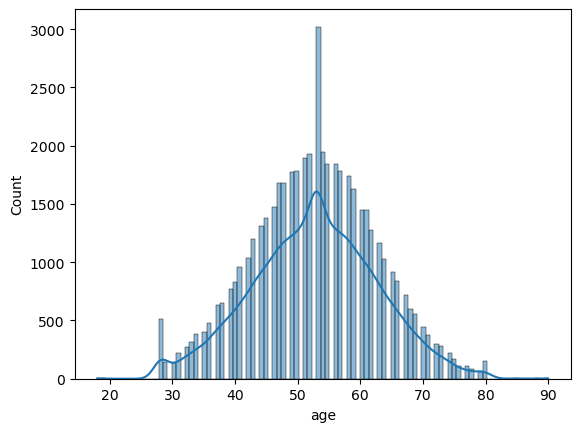

['sex']


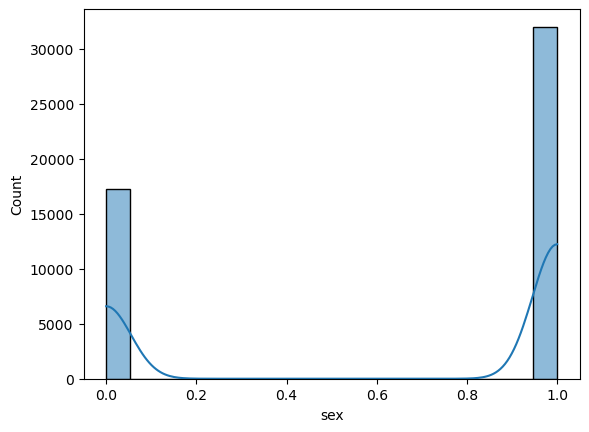

['chest_pain_type']


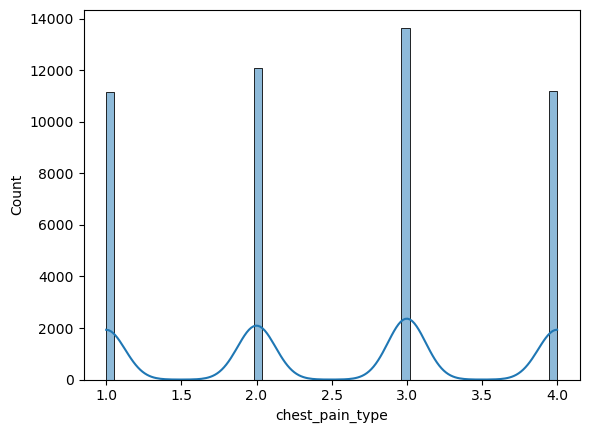

['resting_bp']


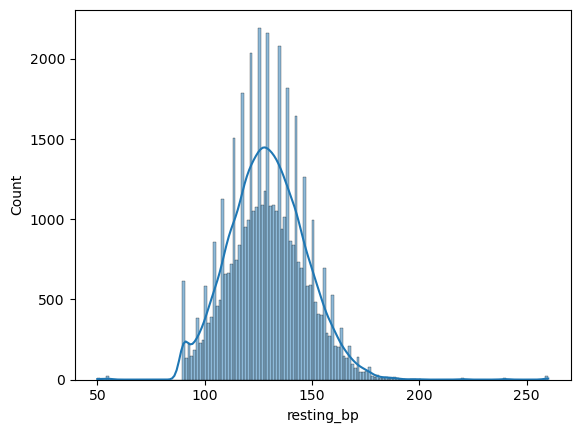

['cholesterol']


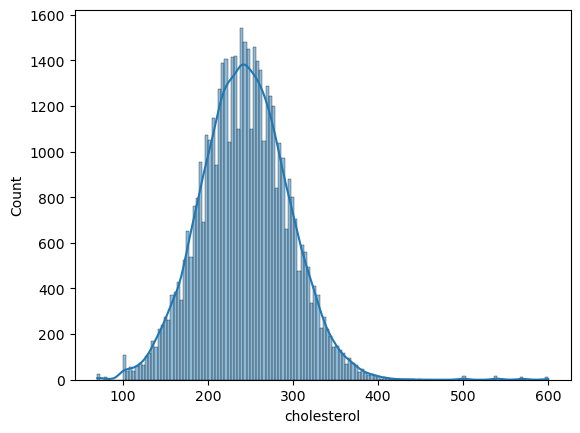

['fasting_blood_sugar']


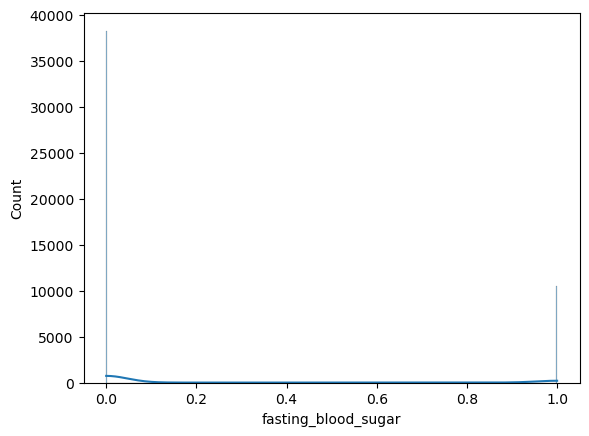

['resting_ecg']


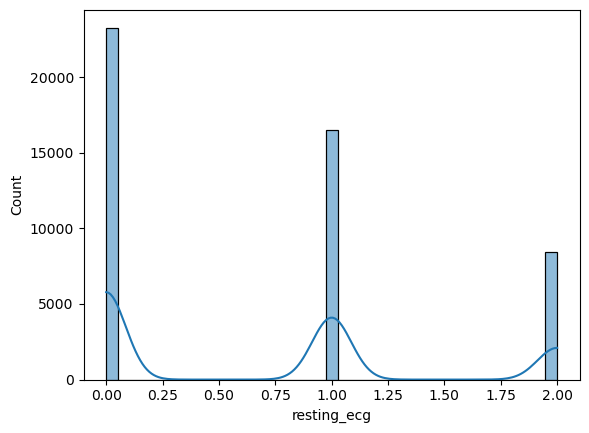

['max_heart_rate']


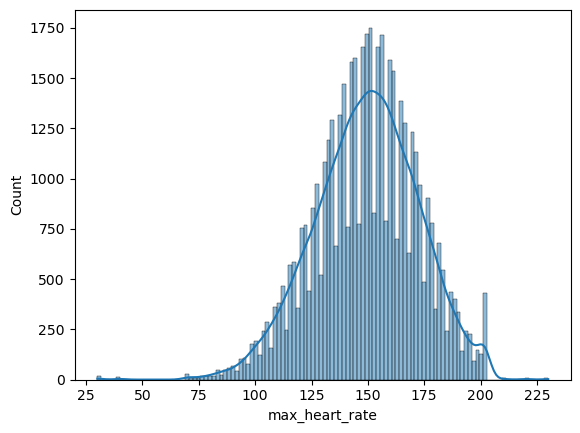

['exercise_angina']


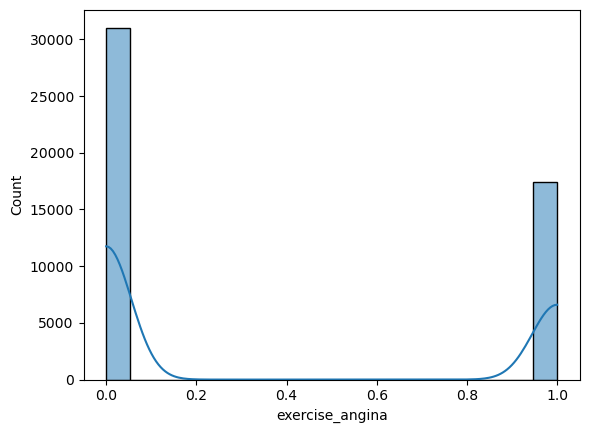

['st_depression']


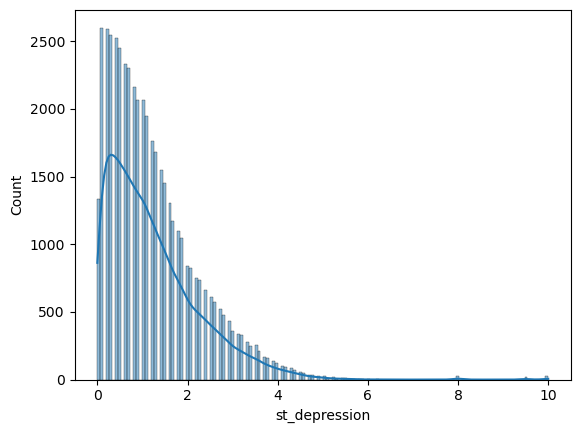

In [29]:
b=['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression']
for i in b :
    print([i])
    sns.histplot(df[i],kde = True)
    plt.show()

In [30]:
df.isna().sum()

age                       0
sex                     723
chest_pain_type        1930
resting_bp             1536
cholesterol            2534
fasting_blood_sugar    1263
resting_ecg            1797
max_heart_rate         1944
exercise_angina        1530
st_depression          2265
target                    0
dtype: int64

In [31]:
dt = df. copy()
dt

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
0,49,0.0,3.0,129.0,168.0,0.0,1.0,147.0,0.0,1.1,0
1,67,1.0,1.0,147.0,228.0,0.0,0.0,119.0,0.0,0.9,1
2,62,0.0,3.0,109.0,171.0,0.0,1.0,129.0,1.0,3.2,1
3,49,1.0,3.0,126.0,239.0,0.0,2.0,130.0,0.0,0.5,1
4,40,0.0,4.0,119.0,182.0,0.0,1.0,165.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
49995,48,1.0,1.0,126.0,185.0,0.0,0.0,139.0,0.0,0.1,1
49996,57,1.0,3.0,95.0,208.0,0.0,0.0,187.0,0.0,0.6,0
49997,67,1.0,1.0,NaN,212.0,0.0,2.0,169.0,0.0,0.9,1
49998,46,1.0,4.0,120.0,161.0,1.0,0.0,149.0,0.0,NaN,0


## Preprocessing

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h3 style="
    color:#991B1B;
    font-size:22px;
    font-weight:600;
    margin:0;
">
Filling Missing Values
</h3>

</div>

In [32]:
dt.isna().sum()[dt.isna().sum()>0]

sex                     723
chest_pain_type        1930
resting_bp             1536
cholesterol            2534
fasting_blood_sugar    1263
resting_ecg            1797
max_heart_rate         1944
exercise_angina        1530
st_depression          2265
dtype: int64

In [33]:
dt['sex'] = dt['sex'].fillna(dt['sex'].mode()[0])

In [34]:
dt['chest_pain_type'] = dt['chest_pain_type'].fillna(dt['chest_pain_type'].mode()[0])

In [35]:
dt['resting_bp'] = dt['resting_bp'].fillna(dt['resting_bp'].median())

In [36]:
dt['cholesterol'] = dt['cholesterol'].fillna(dt['cholesterol'].median())

In [37]:
dt['fasting_blood_sugar'] = dt['fasting_blood_sugar'].fillna(dt['fasting_blood_sugar'].mode()[0])

In [38]:
dt['resting_ecg'] = dt['resting_ecg'].fillna(dt['resting_ecg'].mode()[0])

In [39]:
dt['max_heart_rate'] = dt['max_heart_rate'].fillna(dt['max_heart_rate'].median())

In [40]:
dt['exercise_angina'] = dt['exercise_angina'].fillna(dt['exercise_angina'].mode()[0])

In [41]:
dt['st_depression'] = dt['st_depression'].fillna(dt['st_depression'].median())

In [42]:
dt.isna().sum()

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
target                 0
dtype: int64

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h3 style="
    color:#991B1B;
    font-size:22px;
    font-weight:600;
    margin:0;
">
Outliers treating</h3>

</div>

<Figure size 1200x600 with 0 Axes>

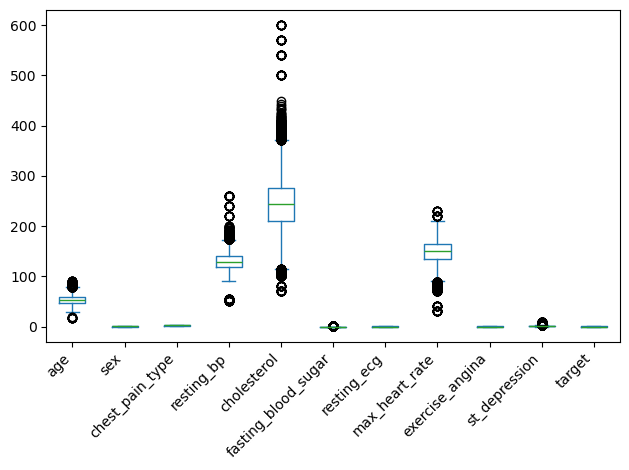

In [43]:
plt.figure(figsize=(12,6))
dt.plot(kind='box')  # or your plot

plt.xticks(rotation=45, ha='right')  # rotate + align
plt.tight_layout()  # adjust spacing
plt.show()

In [44]:
upper_limit = dt['age'].quantile(0.98)
lower_limit = dt['age'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 73.0
lower_limit: 28.0


In [45]:
print(list(map(int,sorted(df['age'].unique()))))

[18, 19, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 85, 88, 90]


In [46]:
upper_limit = dt['resting_bp'].quantile(0.98)
lower_limit = dt['resting_bp'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 166.0
lower_limit: 90.0


In [47]:
dt.loc[(dt['resting_bp']> upper_limit) | (dt['resting_bp'] <lower_limit)]

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
7,49,1.0,2.0,175.0,243.0,0.0,0.0,150.0,0.0,0.8,1
9,46,1.0,2.0,177.0,166.0,1.0,1.0,151.0,1.0,0.6,1
121,56,1.0,1.0,168.0,167.0,0.0,2.0,148.0,0.0,3.4,1
217,56,0.0,2.0,169.0,172.0,0.0,0.0,104.0,1.0,0.7,1
242,54,1.0,4.0,167.0,209.0,0.0,1.0,142.0,1.0,3.2,1
...,...,...,...,...,...,...,...,...,...,...,...
49518,49,1.0,2.0,260.0,260.0,0.0,0.0,123.0,1.0,0.3,0
49710,49,1.0,2.0,55.0,269.0,0.0,0.0,160.0,0.0,0.1,0
49755,46,1.0,4.0,183.0,373.0,1.0,1.0,117.0,1.0,0.8,1
49937,66,0.0,2.0,169.0,274.0,0.0,0.0,128.0,0.0,0.3,1


In [48]:
dt.loc[(dt['resting_bp'] >upper_limit),'resting_bp'] =upper_limit
dt.loc[(dt['resting_bp'] <lower_limit),'resting_bp'] =lower_limit

<Axes: ylabel='resting_bp'>

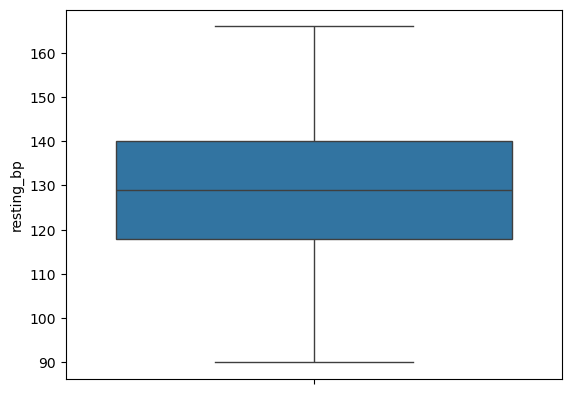

In [49]:
sns.boxplot(dt['resting_bp'])

In [50]:
upper_limit = dt['cholesterol'].quantile(0.98)
lower_limit = dt['cholesterol'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 349.0
lower_limit: 127.0


In [51]:
dt.loc[(dt['cholesterol'] >upper_limit),'cholesterol'] =upper_limit
dt.loc[(dt['cholesterol'] <lower_limit),'cholesterol'] =lower_limit

<Axes: ylabel='cholesterol'>

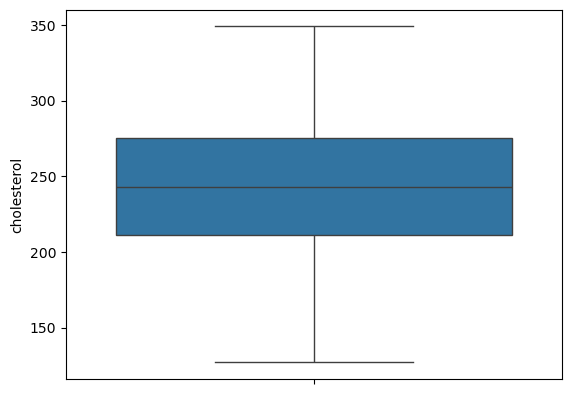

In [52]:
sns.boxplot(dt['cholesterol'])

In [53]:
upper_limit = dt['fasting_blood_sugar'].quantile(0.95)
lower_limit = dt['fasting_blood_sugar'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 1.0
lower_limit: 0.0


In [54]:
dt.loc[(dt['fasting_blood_sugar'] >upper_limit),'fasting_blood_sugar'] =upper_limit
dt.loc[(dt['fasting_blood_sugar'] <lower_limit),'fasting_blood_sugar'] =lower_limit

<Axes: ylabel='fasting_blood_sugar'>

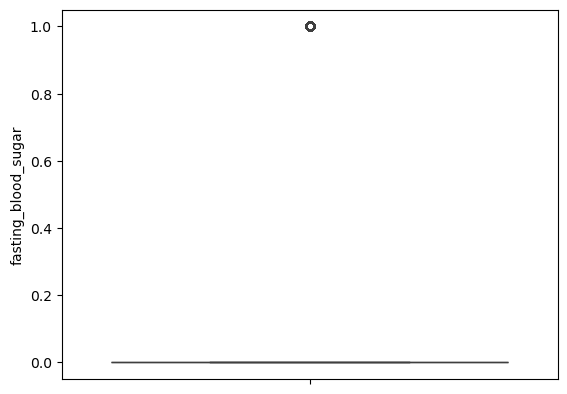

In [55]:
sns.boxplot(dt['fasting_blood_sugar'])

In [56]:
print(list(map(float,sorted(dt['fasting_blood_sugar'].unique()))))

[0.0, 1.0]


In [57]:
upper_limit = dt['max_heart_rate'].quantile(0.95)
lower_limit = dt['max_heart_rate'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 186.0
lower_limit: 94.0


In [58]:
dt.loc[(dt['max_heart_rate'] >upper_limit),'max_heart_rate'] =upper_limit
dt.loc[(dt['max_heart_rate'] <lower_limit),'max_heart_rate'] =lower_limit

<Axes: ylabel='max_heart_rate'>

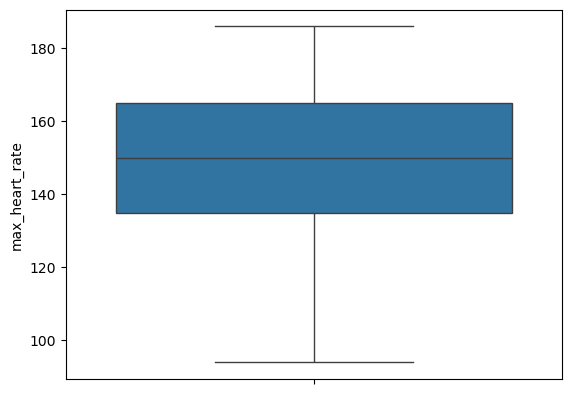

In [59]:
sns.boxplot(dt['max_heart_rate'])

In [60]:
upper_limit = dt['st_depression'].quantile(0.95)
lower_limit = dt['st_depression'].quantile(0.01)
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 3.2
lower_limit: 0.0


In [61]:
dt.loc[(dt['st_depression'] >upper_limit),'st_depression'] =upper_limit
dt.loc[(dt['st_depression'] <lower_limit),'st_depression'] =lower_limit

<Axes: ylabel='st_depression'>

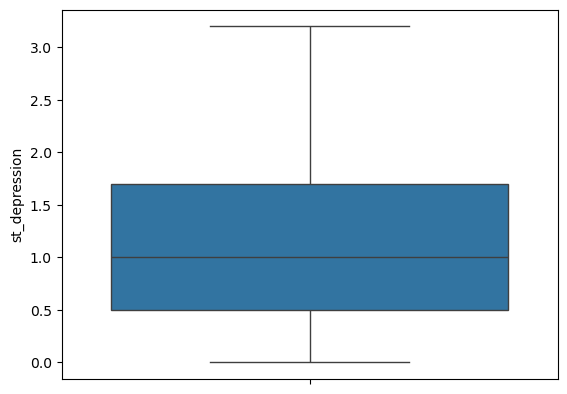

In [62]:
sns.boxplot(dt['st_depression'])

<Figure size 1200x600 with 0 Axes>

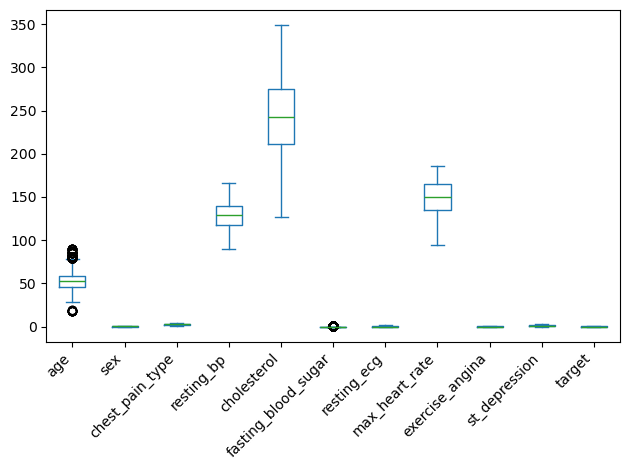

In [63]:
plt.figure(figsize=(12,6))
dt.plot(kind='box')  # or your plot

plt.xticks(rotation=45, ha='right')  # rotate + align
plt.tight_layout()  # adjust spacing
plt.show()

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h3 style="
    color:#991B1B;
    font-size:22px;
    font-weight:600;
    margin:0;
">
Data Splitting
</h3>

</div>

In [64]:
x= dt.drop(['target'],axis=1)
y = dt['target']
x

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression
0,49,0.0,3.0,129.0,168.0,0.0,1.0,147.0,0.0,1.1
1,67,1.0,1.0,147.0,228.0,0.0,0.0,119.0,0.0,0.9
2,62,0.0,3.0,109.0,171.0,0.0,1.0,129.0,1.0,3.2
3,49,1.0,3.0,126.0,239.0,0.0,2.0,130.0,0.0,0.5
4,40,0.0,4.0,119.0,182.0,0.0,1.0,165.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
49995,48,1.0,1.0,126.0,185.0,0.0,0.0,139.0,0.0,0.1
49996,57,1.0,3.0,95.0,208.0,0.0,0.0,186.0,0.0,0.6
49997,67,1.0,1.0,129.0,212.0,0.0,2.0,169.0,0.0,0.9
49998,46,1.0,4.0,120.0,161.0,1.0,0.0,149.0,0.0,1.0


<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h3 style="
    color:#991B1B;
    font-size:22px;
    font-weight:600;
    margin:0;
">
Train Test Split</h3>

</div>

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3 ,random_state =42)

In [66]:
from sklearn . preprocessing  import  StandardScaler

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h3 style="
    color:#991B1B;
    font-size:22px;
    font-weight:600;
    margin:0;
">
Scaling
</h3>

</div>

In [67]:
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test  = ss.transform(x_test)
x_train

array([[-0.26963617,  0.72809445,  0.43548359, ..., -0.3764375 ,
        -0.7312208 ,  0.01042986],
       [-0.8696213 ,  0.72809445,  0.43548359, ..., -0.23702309,
        -0.7312208 , -0.21687091],
       [ 0.23035143,  0.72809445,  0.43548359, ..., -0.51585191,
         1.36757598, -0.21687091],
       ...,
       [-0.16963865, -1.37344817, -1.43675886, ...,  1.29653544,
        -0.7312208 , -1.35337477],
       [-1.3696089 ,  0.72809445, -0.50063763, ...,  0.18122015,
        -0.7312208 ,  2.28343757],
       [-0.66962626,  0.72809445,  0.43548359, ...,  0.50652044,
         1.36757598, -1.01242361]], shape=(35000, 10))

In [68]:
x_train_DF = pd.DataFrame(x_train)
x_train_DF

,0,1,2,3,4,5,6,7,8,9
0,-0.269636,0.728094,0.435484,-1.536871,0.718874,-0.511315,-0.896423,-0.376437,-0.731221,0.010430
1,-0.869621,0.728094,0.435484,-0.236059,0.450011,-0.511315,1.774341,-0.237023,-0.731221,-0.216871
2,0.230351,0.728094,0.435484,0.473475,1.380690,-0.511315,0.438959,-0.515852,1.367576,-0.216871
3,-0.369634,-1.373448,-1.436759,2.010799,1.049782,-0.511315,0.438959,-0.655266,1.367576,-1.239724
4,0.330349,-1.373448,0.435484,-0.768209,-0.004987,-0.511315,-0.896423,-0.469380,-0.731221,0.010430
...,...,...,...,...,...,...,...,...,...,...
34995,0.330349,0.728094,-1.436759,0.059581,1.608190,-0.511315,-0.896423,-0.515852,-0.731221,1.260584
34996,-0.569629,0.728094,0.435484,-0.058675,-0.687485,-0.511315,-0.896423,1.017707,1.367576,-0.898773
34997,-0.169639,-1.373448,-1.436759,-0.472570,-0.439304,-0.511315,-0.896423,1.296535,-0.731221,-1.353375
34998,-1.369609,0.728094,-0.500638,0.000453,2.187279,-0.511315,0.438959,0.181220,-0.731221,2.283438


<div style="
    font-family:'Segoe UI', Roboto, Arial, sans-serif;
    margin-top:25px;
    padding:12px 18px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h2 style="
    color:#7F1D1D;
    font-size:35px;
    font-weight:600;
    margin:0;
    letter-spacing:0.5px;
">
Model Building (Initial)
</h2>

</div>

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:10px;
    padding:5px 10px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
K-Nearest Neighbors (KNN)
</h3>

</div>

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [70]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
y_pred = knn.predict(x_test)
print(y_pred)

[0 1 0 ... 0 1 0]


In [72]:
knn_acc = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',knn_acc)

Accuracy Score - 81.67999999999999


Test Score: 81.67999999999999
Train Score: 89.52


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      8277
           1       0.82      0.76      0.79      6723

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix:
 [[7125 1152]
 [1596 5127]]


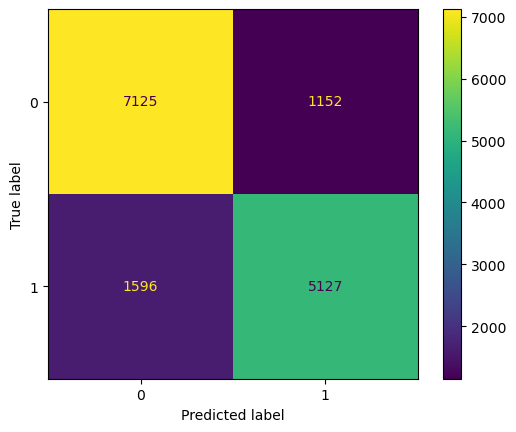

In [73]:
print('Test Score:',knn.score(x_test,y_test)*100)
print('Train Score:',knn.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Naive Bayes (GaussianNB)
</h3>

</div>

In [74]:
from sklearn.naive_bayes import GaussianNB

In [75]:
model = GaussianNB()
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [76]:
y_pred1 = model.predict(x_test)
y_pred1 

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [77]:
model_acc = accuracy_score(y_test,y_pred1)*100
print('Accuracy Score -',model_acc)

Accuracy Score - 84.24666666666667


Test Score: 84.24666666666667
Train Score: 84.70857142857143


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      8277
           1       0.84      0.81      0.82      6723

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000


Confusion Matrix:
 [[7216 1061]
 [1302 5421]]


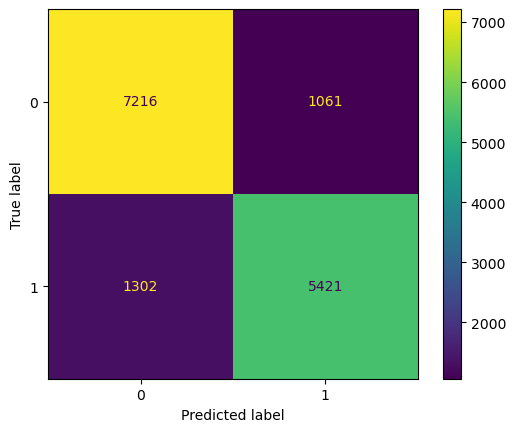

In [78]:
print('Test Score:',model.score(x_test,y_test)*100)
print('Train Score:',model.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred1))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred1))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred1))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Support Vector Classifier (SVC)
</h3>

</div>

In [79]:
from  sklearn.svm import SVC

In [80]:
svc = SVC(kernel='rbf', C=10, gamma=0.01)
svc.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
y_pred2=svc.predict(x_test)
y_pred2

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [82]:
svc_acc = accuracy_score(y_test,y_pred2)*100
print('Accuracy Score -',svc_acc)

Accuracy Score - 85.03333333333333


Test Score: 85.03333333333333
Train Score: 85.61142857142858


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      8277
           1       0.87      0.78      0.82      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.85     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7524  753]
 [1492 5231]]


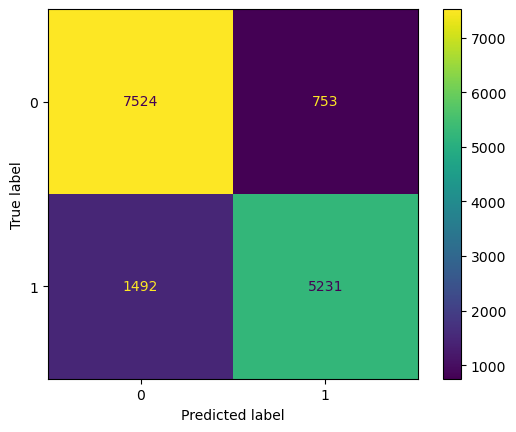

In [83]:
print('Test Score:',svc.score(x_test,y_test)*100)
print('Train Score:',svc.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred2))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred2))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred2))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Logistic Regression
</h3>

</div>

In [84]:
from sklearn.linear_model import LogisticRegression

In [85]:
log = LogisticRegression()
log.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [86]:
y_pred3=log.predict(x_test)
y_pred3

array([0, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [87]:
log_acc = accuracy_score(y_test,y_pred3)*100
print('Accuracy Score -',log_acc)

Accuracy Score - 84.14666666666668


Test Score: 84.14666666666668
Train Score: 84.68571428571428


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      8277
           1       0.84      0.80      0.82      6723

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000


Confusion Matrix:
 [[7255 1022]
 [1356 5367]]


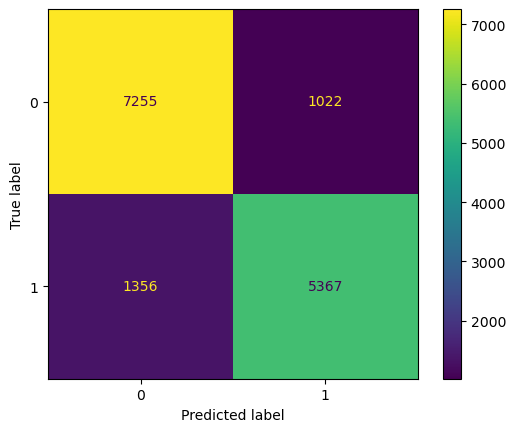

In [88]:
print('Test Score:',log.score(x_test,y_test)*100)
print('Train Score:',log.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred3))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred3))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred3))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Decision Tree
</h3>

</div>

In [89]:
from sklearn.tree import DecisionTreeClassifier

In [90]:
tree = DecisionTreeClassifier(max_depth=7)
tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [91]:
y_pred4 =tree.predict(x_test)
y_pred4

array([0, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [92]:
tree_acc = accuracy_score(y_test,y_pred4)*100
print('Accuracy Score -',tree_acc)

Accuracy Score - 81.53333333333333


Test Score: 81.53333333333333
Train Score: 83.29142857142857


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84      8277
           1       0.83      0.74      0.78      6723

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.81     15000


Confusion Matrix:
 [[7247 1030]
 [1740 4983]]


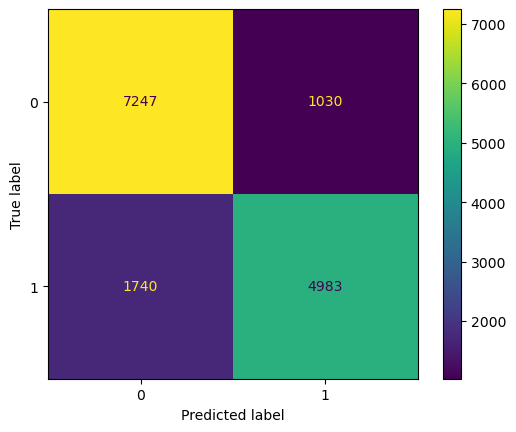

In [93]:
print('Test Score:',tree.score(x_test,y_test)*100)
print('Train Score:',tree.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred4))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred4))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred4))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
 XG Boost
</h3>

</div>

In [94]:
!pip install xgboost

In [95]:
from xgboost import XGBClassifier

In [96]:
xgboost=XGBClassifier(n_estimators=100 ,estimator =None,learning_rate =0.2,random_state =42)
xgboost.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [97]:
y_pred5=xgboost.predict(x_test)
y_pred5

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [98]:
xgboost_acc = accuracy_score(y_test,y_pred5)*100
print('Accuracy Score -',xgboost_acc)

Accuracy Score - 84.58


Test Score: 84.58
Train Score: 89.00285714285714


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      8277
           1       0.85      0.80      0.82      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.84     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7319  958]
 [1355 5368]]


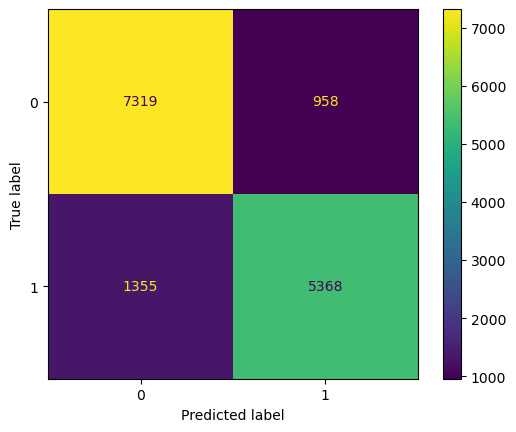

In [99]:
print('Test Score:',xgboost.score(x_test,y_test)*100)
print('Train Score:',xgboost.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred5))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred5))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred5))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Ada Boost
</h3>

</div>

In [100]:
from sklearn.ensemble import AdaBoostClassifier

In [101]:
ada=AdaBoostClassifier(n_estimators=100,learning_rate=0.5,random_state=42)
ada.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [102]:
y_pred6=ada.predict(x_test)
y_pred6

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [103]:
ada_acc = accuracy_score(y_test,y_pred6)*100
print('Accuracy Score -',ada_acc)

Accuracy Score - 84.72666666666666


Test Score: 84.72666666666666
Train Score: 85.16571428571429


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      8277
           1       0.86      0.78      0.82      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.84     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7449  828]
 [1463 5260]]


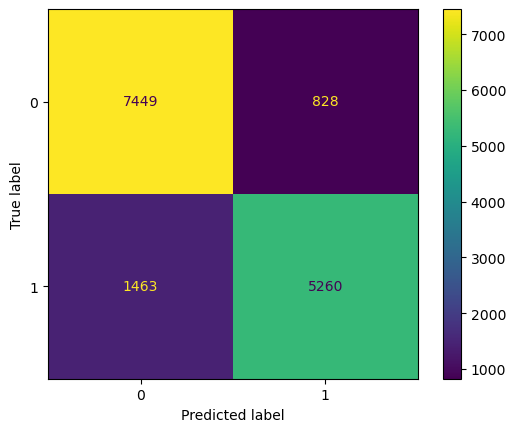

In [104]:
print('Test Score:',ada.score(x_test,y_test)*100)
print('Train Score:',ada.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred6))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred6))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred6))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Gradient Boost
</h3>

</div>

In [105]:
from sklearn.ensemble import GradientBoostingClassifier

In [106]:
gb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.2,random_state=42)
gb.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [107]:
y_pred7=gb.predict(x_test)
y_pred7

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [108]:
gb_acc = accuracy_score(y_test,y_pred7)*100
print('Accuracy Score -',gb_acc)

Accuracy Score - 84.94


Test Score: 84.94
Train Score: 86.24000000000001


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      8277
           1       0.85      0.80      0.83      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.85      0.85     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7343  934]
 [1325 5398]]


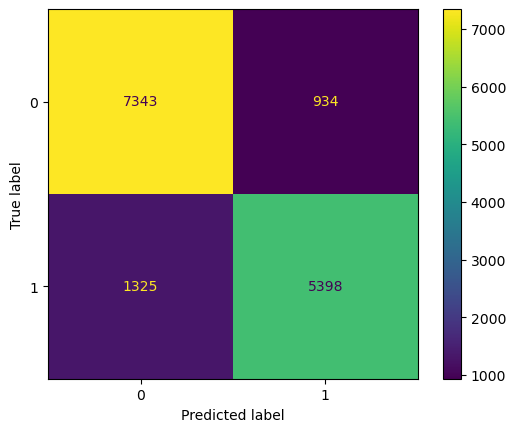

In [109]:
print('Test Score:',gb.score(x_test,y_test)*100)
print('Train Score:',gb.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred7))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred7))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred7))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:28px;
    font-weight:600;
    margin:0;
">
Random Forest
</h3>

</div>

In [110]:
from sklearn.ensemble import RandomForestClassifier

In [111]:
rf = RandomForestClassifier(n_estimators =100 ,random_state =42)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [112]:
y_pred8 =rf.predict(x_test)
y_pred8

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [113]:
rf_acc = accuracy_score(y_test,y_pred8)*100
print('Accuracy Score -',rf_acc)

Accuracy Score - 84.39333333333333


Test Score: 84.39333333333333
Train Score: 99.99428571428571


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      8277
           1       0.85      0.80      0.82      6723

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000


Confusion Matrix:
 [[7295  982]
 [1359 5364]]


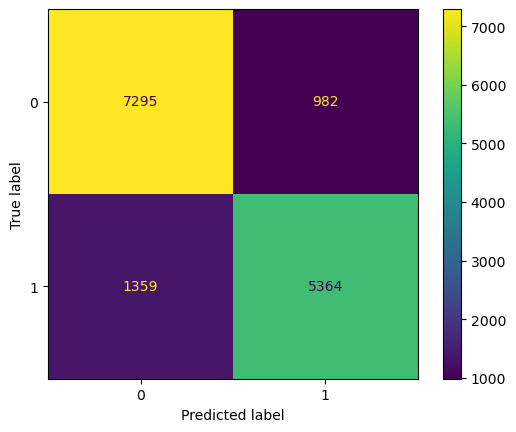

In [114]:
print('Test Score:',rf.score(x_test,y_test)*100)
print('Train Score:',rf.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred8))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred8))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred8))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#006400;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Initial Accuracy
</h3>

</div>

In [115]:
tbb=pd.DataFrame()
tbb['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','SVC','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier'])
tbb['Initial Accuracy']=pd.Series([knn_acc,model_acc,svc_acc,log_acc,tree_acc,xgboost_acc,ada_acc,gb_acc,rf_acc])
tbb.sort_values(by='Initial Accuracy', ascending=False).reset_index(drop=True)

,Model,Initial Accuracy
0,SVC,85.033333
1,GradientBoostingClassifier,84.940000
2,AdaBoostClassifier,84.726667
3,XGBClassifier,84.580000
4,RandomForestClassifier,84.393333
5,GaussianNB,84.246667
6,LogisticRegression,84.146667
7,KNeighborsClassifier,81.680000
8,DecisionTreeClassifier,81.533333


In [116]:
dt['target'].value_counts()

target
0    27574
1    22426
Name: count, dtype: int64

<div style="
    font-family:'Segoe UI', Roboto, Arial, sans-serif;
    margin-top:25px;
    padding:12px 18px;
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    border-radius:6px;
">

<h2 style="
    color:#7F1D1D;
    font-size:35px;
    font-weight:600;
    margin:0;
    letter-spacing:0.5px;
">
Hyperparameter Tuning
</h2>

</div>

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
 K-Nearest Neighbors (KNN)</h3>

</div>

In [117]:
from sklearn.model_selection import GridSearchCV

In [118]:
knn=KNeighborsClassifier()    
par={'n_neighbors':[3,5,7,9],'weights':['uniform','distance']}
knn_t=GridSearchCV(knn,par,cv=5,scoring='accuracy')
knn_t.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [119]:
print(knn_t.best_params_)
print(knn_t.best_score_) 

{'n_neighbors': 9, 'weights': 'uniform'}
0.837


In [120]:
knn2=KNeighborsClassifier(n_neighbors=9,weights='uniform') 
knn2.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [121]:
y_pred=knn2.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [122]:
knn_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',knn_acc2)

Accuracy Score - 83.43333333333334


Test Score: 83.43333333333334
Train Score: 86.60571428571428


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      8277
           1       0.85      0.77      0.81      6723

    accuracy                           0.83     15000
   macro avg       0.84      0.83      0.83     15000
weighted avg       0.84      0.83      0.83     15000


Confusion Matrix:
 [[7330  947]
 [1538 5185]]


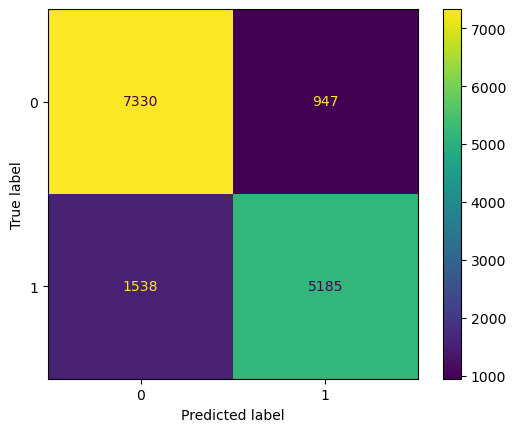

In [123]:
print('Test Score:',knn2.score(x_test,y_test)*100)
print('Train Score:',knn2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
 Naive Bayes (GaussianNB)
</h3>

</div>

In [124]:
model2 = GaussianNB()
model2.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [125]:
y_pred= model2.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [126]:
model_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',model_acc2)

Accuracy Score - 84.24666666666667


Test Score: 84.24666666666667
Train Score: 84.70857142857143


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      8277
           1       0.84      0.81      0.82      6723

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000


Confusion Matrix:
 [[7216 1061]
 [1302 5421]]


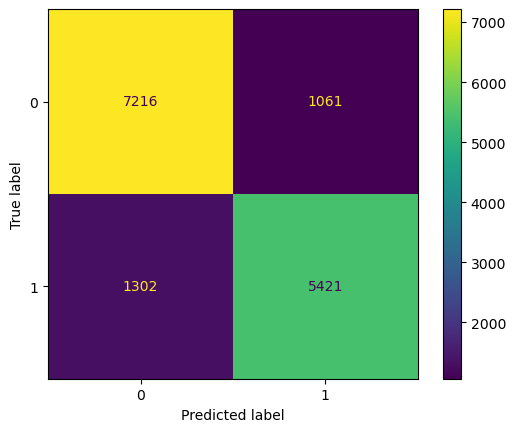

In [127]:
print('Test Score:',model2.score(x_test,y_test)*100)
print('Train Score:',model2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Support Vector Classifier (SVC)
</h3>

</div>

In [128]:
# svc=SVC()
# par={'C':[0.1,1,10,100],'gamma':['scale','auto',0.1,0.01]}
# svc_t=GridSearchCV(svc,par,cv=3,scoring='accuracy',n_jobs=-1)
# svc_t.fit(x_train,y_train)
# print(svc_t.best_params_)
# print(svc_t.best_score_)

In [129]:
# svc2=SVC(C=10, gamma='l2') 
# svc2.fit(x_train,y_train)

In [130]:
# y_pred=svc2.predict(x_test)
# y_pred

In [131]:
# svc_acc2 = accuracy_score(y_test,y_pred)*100
# print('Accuracy Score -',svc_acc2)

In [132]:
# print('Test Score:',svc2.score(x_test,y_test)*100)
# print('Train Score:',svc2.score(x_train,y_train)*100)
# print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
# print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
# print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Logistic Regression
</h3>

</div>

In [133]:
log2=LogisticRegression(C=10, penalty='l2') 
log2.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [134]:
y_pred=log2.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [135]:
log_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',log_acc2)

Accuracy Score - 84.14666666666668


Test Score: 84.14666666666668
Train Score: 84.68571428571428


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      8277
           1       0.84      0.80      0.82      6723

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000


Confusion Matrix:
 [[7255 1022]
 [1356 5367]]


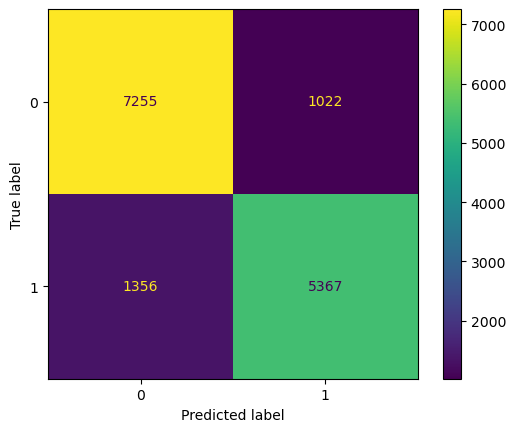

In [136]:
print('Test Score:',log2.score(x_test,y_test)*100)
print('Train Score:',log2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Decision Tree
</h3>

</div>

In [137]:
tree = DecisionTreeClassifier()
par={'max_depth':[3,5,7,10,15,20],'min_samples_split':[2,5,10,20]}
tree_t=GridSearchCV(tree,par,cv=5,scoring='accuracy',n_jobs=-1)
tree_t.fit(x_train,y_train) 
print(tree_t.best_params_)
print(tree_t.best_score_)

{'max_depth': 10, 'min_samples_split': 20}
0.8224571428571428


In [138]:
tree2=DecisionTreeClassifier(max_depth=20,min_samples_split=2) 
tree2.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [139]:
y_pred=tree2.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [140]:
tree_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',tree_acc2)

Accuracy Score - 77.75333333333333


Test Score: 77.75333333333333
Train Score: 99.15142857142857


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80      8277
           1       0.76      0.74      0.75      6723

    accuracy                           0.78     15000
   macro avg       0.78      0.77      0.77     15000
weighted avg       0.78      0.78      0.78     15000


Confusion Matrix:
 [[6668 1609]
 [1728 4995]]


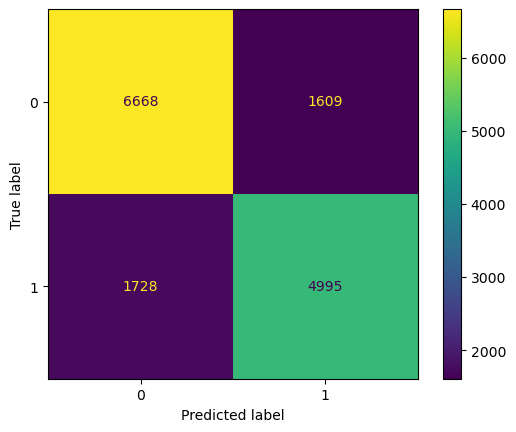

In [141]:
print('Test Score:',tree2.score(x_test,y_test)*100)
print('Train Score:',tree2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
XG Boost
</h3>

</div>

In [142]:
xgboost=XGBClassifier()
par={'max_depth': [3, 5, 7, 10],'learning_rate': [0.01, 0.05, 0.1, 0.3],'n_estimators': [100, 200, 300]}
xgboost_t=GridSearchCV(xgboost,par,cv=5,scoring='accuracy',n_jobs=-1)
xgboost_t.fit(x_train,y_train) 
print(xgboost_t.best_params_)
print(xgboost_t.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
0.8544


In [143]:
xgboost2=XGBClassifier(learning_rate=0.3,max_depth =7,n_estimators=300) 
xgboost2.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [144]:
y_pred=xgboost2.predict(x_test)
y_pred

array([1, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [145]:
xgboost_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',xgboost_acc2)

Accuracy Score - 83.37333333333333


Test Score: 83.37333333333333
Train Score: 98.20857142857143


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85      8277
           1       0.83      0.79      0.81      6723

    accuracy                           0.83     15000
   macro avg       0.83      0.83      0.83     15000
weighted avg       0.83      0.83      0.83     15000


Confusion Matrix:
 [[7175 1102]
 [1392 5331]]


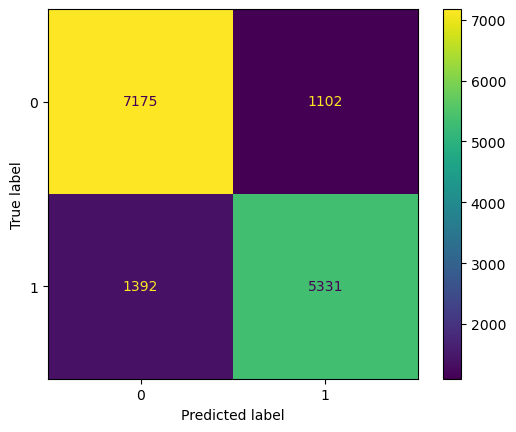

In [146]:
print('Test Score:',xgboost2.score(x_test,y_test)*100)
print('Train Score:',xgboost2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Ada Boost
</h3>

</div>

In [147]:
ada=AdaBoostClassifier()
par={'n_estimators':[50, 100, 150, 200],'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]}
ada_t=GridSearchCV(ada,par,cv=5,scoring='accuracy',n_jobs=-1)
ada_t.fit(x_train,y_train)
print(ada_t.best_params_)
print(ada_t.best_score_)

{'learning_rate': 1.0, 'n_estimators': 200}
0.8542571428571428


In [148]:
ada2=AdaBoostClassifier(learning_rate=0.5,n_estimators=150) 
ada2.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",150
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [149]:
y_pred=ada2.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [150]:
ada_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',ada_acc2)

Accuracy Score - 84.81333333333333


Test Score: 84.81333333333333
Train Score: 85.29142857142857


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      8277
           1       0.86      0.79      0.82      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.85     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7402  875]
 [1403 5320]]


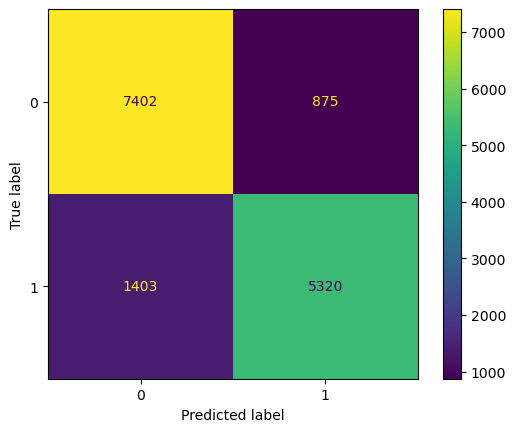

In [151]:
print('Test Score:',ada2.score(x_test,y_test)*100)
print('Train Score:',ada2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Gradient Boost
</h3>

</div>

In [152]:
gb=GradientBoostingClassifier()
par={ 'n_estimators': [50, 100, 150, 200],'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]}
gb_t=GridSearchCV(gb,par,cv=5,scoring='accuracy',n_jobs=-1)
gb_t.fit(x_train,y_train)
print(gb_t.best_params_)
print(gb_t.best_score_)

{'learning_rate': 0.1, 'n_estimators': 150}
0.8537142857142858


In [153]:
gb2=GradientBoostingClassifier(learning_rate=0.5,n_estimators=100) 
gb2.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.5
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [154]:
y_pred=gb2.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [155]:
gb_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',gb_acc2)

Accuracy Score - 84.89999999999999


Test Score: 84.89999999999999
Train Score: 86.66857142857143


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87      8277
           1       0.85      0.80      0.83      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.85     15000
weighted avg       0.85      0.85      0.85     15000


Confusion Matrix:
 [[7325  952]
 [1313 5410]]


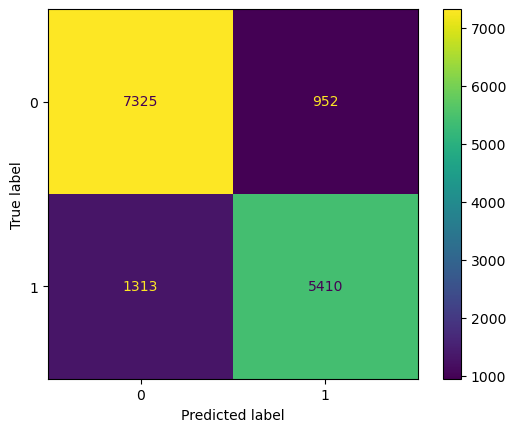

In [156]:
print('Test Score:',gb2.score(x_test,y_test)*100)
print('Train Score:',gb2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

<div style="
    font-family:'Segoe UI', Roboto, sans-serif;
    margin-top:25px;
    padding:10px 15px;
    background: white;
    border-radius:6px;
">

<h3 style="
    color:#1E40AF;
    font-size:30px;
    font-weight:600;
    margin:0;
">
Random Forest
</h3>

</div>

In [157]:
rf=RandomForestClassifier()
par={'n_estimators': [100, 200],'max_depth': [5, 10, 15]}
rf_t=GridSearchCV(rf,par,cv=5,scoring='accuracy',n_jobs=-1)
rf_t.fit(x_train,y_train)
print(rf_t.best_params_)
print(rf_t.best_score_)

{'max_depth': 10, 'n_estimators': 100}
0.8503714285714284


In [158]:
rf2=RandomForestClassifier(max_depth=15 ,n_estimators=200) 
rf2.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [159]:
y_pred=rf2.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [160]:
rf_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',rf_acc2)

Accuracy Score - 84.51333333333334


Test Score: 84.51333333333334
Train Score: 96.40857142857143


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      8277
           1       0.85      0.79      0.82      6723

    accuracy                           0.85     15000
   macro avg       0.85      0.84      0.84     15000
weighted avg       0.85      0.85      0.84     15000


Confusion Matrix:
 [[7337  940]
 [1383 5340]]


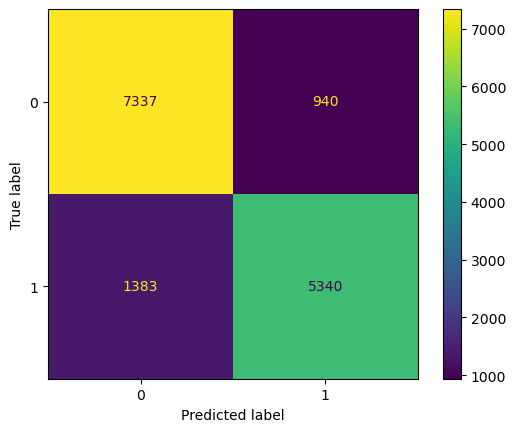

In [161]:
print('Test Score:',rf2.score(x_test,y_test)*100)
print('Train Score:',rf2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [162]:
tbz=pd.DataFrame()
tbz['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier','SVC'])
tbz['Initial Accuracy']=pd.Series([knn_acc,model_acc,log_acc,tree_acc,xgboost_acc,ada_acc,gb_acc,rf_acc,svc_acc])
tbz['Accuracy_Hyperparameter Tuning']=pd.Series([knn_acc2,model_acc2,log_acc2,tree_acc2,xgboost_acc2,ada_acc2,gb_acc2,rf_acc2])
tbz.sort_values(by= ['Initial Accuracy','Accuracy_Hyperparameter Tuning'], ascending=False).reset_index(drop=True)

,Model,Initial Accuracy,Accuracy_Hyperparameter Tuning
0,SVC,85.033333,NaN
1,GradientBoostingClassifier,84.940000,84.900000
2,AdaBoostClassifier,84.726667,84.813333
3,XGBClassifier,84.580000,83.373333
4,RandomForestClassifier,84.393333,84.513333
5,GaussianNB,84.246667,84.246667
6,LogisticRegression,84.146667,84.146667
7,KNeighborsClassifier,81.680000,83.433333
8,DecisionTreeClassifier,81.533333,77.753333


In [163]:
knn_train=knn2.score(x_train,y_train)
model_train=model2.score(x_train,y_train)
log_train=log2.score(x_train,y_train)
tree_train=tree2.score(x_train,y_train)
xgboost_train=xgboost2.score(x_train,y_train)
ada_train=ada2.score(x_train,y_train)
gb_train=gb2.score(x_train,y_train)
rf_train=rf2.score(x_train,y_train)
#svc_train=svc1.score(x_train,y_train)

In [164]:
ck14=pd.DataFrame()
ck14['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier','SVC'])
ck14['Test Accuracy']=pd.Series([knn_acc2,model_acc2,log_acc2,tree_acc2,xgboost_acc2,ada_acc2,gb_acc2,rf_acc2 ]) #svc_acc1
ck14['Train Accuracy']=pd.Series([knn_train,model_train,log_train,tree_train,xgboost_train,ada_train,gb_train,rf_train]) #svc_train
ck14.sort_values(by= ['Test Accuracy', 'Train Accuracy'], ascending=False).reset_index(drop=True)

,Model,Test Accuracy,Train Accuracy
0,GradientBoostingClassifier,84.900000,0.866686
1,AdaBoostClassifier,84.813333,0.852914
2,RandomForestClassifier,84.513333,0.964086
3,GaussianNB,84.246667,0.847086
4,LogisticRegression,84.146667,0.846857
5,KNeighborsClassifier,83.433333,0.866057
6,XGBClassifier,83.373333,0.982086
7,DecisionTreeClassifier,77.753333,0.991514
8,SVC,NaN,NaN


In [165]:
import joblib

In [166]:
joblib.dump(gb2,r'Heart Disease.pkl')
joblib.dump(ss,r'ss.pkl')

['ss.pkl']